Sample Data: 
    Soil_Nitrogen    Rainfall  Temperature  Water_Usage  Label
0      74.967142  632.408397    17.923146   420.039428      1
1      68.617357  561.491772    22.896773   427.715857      1
2      76.476885  532.307800    23.286427   345.598022      0
3      85.230299  661.167629    20.988614   418.580296      1
4      67.658466  703.099952    24.193571   423.445798      1
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4750 - loss: 0.6766
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5250 - loss: 0.6677 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5750 - loss: 0.6559
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5750 - loss: 0.6465 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6250 - loss: 0.6384
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6750 - loss: 0.6296
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6750 - loss: 0.6199
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7000 - loss: 0.6126
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7000 - loss: 0.6045 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7000 - loss: 0.5971
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6750 - loss: 0.5898
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6750 - loss: 0.5833
Epoch 13/50

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


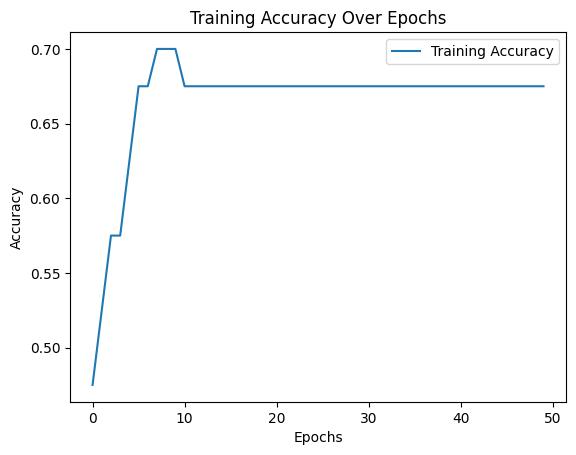

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#1.Generate Dataset(50 samples)

np.random.seed(42)
n_samples = 50

data = pd.DataFrame({
    'Soil_Nitrogen' : np.random.normal(70,10,n_samples),
    'Rainfall': np.random.normal(600,100,n_samples),
    'Temperature': np.random.normal(25,5,n_samples),
    'Water_Usage': np.random.normal(400,80,n_samples)
})

#Create classification label (Healthy = 1,Unhealthy = 0)
data['Label'] = (
    (data['Soil_Nitrogen'] > 65) &
    (data['Rainfall'] > 550) &
    (data['Water_Usage'] > 350)
).astype(int)

print("Sample Data: \n", data.head())

#2.Split Features and Labels

X = data.drop('Label',axis = 1)
y = data['Label']

#3.Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

#4.Feature Scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#5.Build ANN Model

model = Sequential()

#Input + Hidden Layers
model.add(Dense(8, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(6,activation='relu'))

#Output Layer(Binary Classification)
model.add(Dense(1, activation = 'sigmoid'))

#6.Compile Model

model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

#7.Train Model

history = model.fit(
    X_train, y_train,
    epochs = 50,
    batch_size = 5,
    verbose =1
)

#8.Predictions

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

#9.Evaluation Metrics

print("\n----Model Evaluation----")

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ",accuracy)

print("\nConfusion Matrix: \n", confusion_matrix(y_test, y_pred))
print("\nClassification Report: \n", classification_report(y_test,y_pred))

#10.Plot Training Performance

plt.figure()
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Over Epochs")
plt.legend()
plt.show()